## check if RNA data is being scaled properly (globally)

this cell below samples the raw dataset (that's why it is a markdown)

import numpy as np
import pandas as pd
from pathlib import Path

np.random.seed(42)

# -----------------------------
# CONFIG
# -----------------------------

base = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA")

models = [
    {
        "label": "RNA_L18",
        "raw": base / "L_18/plot_a/plot_a_files/Plot_A_RNA_L18_Billion_Samples.csv",
        "out": base / "L_18/plot_b/plot_b_files/RNA_L18_global_local_sampling.csv"
    },
    {
        "label": "RNA_L30",
        "raw": base / "L_30/plot_a/plot_a_files/Plot_A_RNA_L30_Billion_Samples.csv",
        "out": base / "L_30/plot_b/plot_b_files/RNA_L30_global_local_sampling.csv"
    }
]

Ns = [10**k for k in range(1,10)]  # 10^1 to 10^9

# -----------------------------
# FUNCTION
# -----------------------------

def run_sampling(raw_csv_path, out_path):

    print(f"\nProcessing {raw_csv_path}")

    raw = pd.read_csv(raw_csv_path)
    raw.columns = [c.strip() for c in raw.columns]

    raw = raw[raw["Status"] == "Rand"].copy()
    raw["Complexity"] = pd.to_numeric(raw["Complexity"], errors="coerce")
    raw["Freq"] = pd.to_numeric(raw["Freq"], errors="coerce")
    raw = raw.dropna(subset=["Complexity", "Freq"])
    raw = raw[raw["Freq"] > 0]

    complexities = raw["Complexity"].values
    freqs = raw["Freq"].values
    total = freqs.sum()

    probs = freqs / total
    n_unique = len(complexities)

    global_min = complexities.min()
    global_max = complexities.max()
    log2_global_unique = np.log2(n_unique)

    print(f"Global min={global_min:.6f}, max={global_max:.6f}, log2(N_unique)={log2_global_unique:.6f}")

    results = []

    for N in Ns:

        counts = np.random.multinomial(N, probs)

        # Unscaled mean
        unscaled = (counts * complexities).sum() / N

        # Global scaled
        scaled_vals_global = log2_global_unique * (complexities - global_min) / (global_max - global_min)
        global_scaled = (counts * scaled_vals_global).sum() / N

        # Local scaled
        present = counts > 0
        sample_complexities = complexities[present]
        sample_counts = counts[present]

        sample_min = sample_complexities.min()
        sample_max = sample_complexities.max()
        sample_unique = len(sample_complexities)
        log2_sample_unique = np.log2(sample_unique)

        scaled_vals_local = log2_sample_unique * (sample_complexities - sample_min) / (sample_max - sample_min)
        local_scaled = (sample_counts * scaled_vals_local).sum() / N

        # Entropy
        p_sample = sample_counts / N
        S = -np.sum(p_sample * np.log2(p_sample))

        print(f"N={N:10d} | S={S:8.4f} | global={global_scaled:8.4f} | local={local_scaled:8.4f} | unscaled={unscaled:8.4f}")

        results.append({
            "Samples": N,
            "Entropy": S,
            "GlobalScaled": global_scaled,
            "LocalScaled": local_scaled,
            "UnscaledMean": unscaled
        })

    df_out = pd.DataFrame(results)
    df_out.to_csv(out_path, index=False)
    print(f"\nSaved to {out_path}")

# -----------------------------
# RUN
# -----------------------------

for m in models:
    run_sampling(m["raw"], m["out"])

this cell shows the RNA model is currently using local scaling

for purposes of email to kamal i'll call OGSam pre-scaled "local and global" 

cwd: /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_18/plot_b
python executable: /usr/local/bin/python3
process id: 67384
USER: sam

Checking: /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_18/plot_b/plot_b_files/RNA_L18_global_local_sampling.csv
  exists(): True
  size (bytes): 774

Checking: /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_30/plot_b/plot_b_files/RNA_L30_global_local_sampling.csv
  exists(): True
  size (bytes): 768

Checking: /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_18/plot_b/plot_b_files/Plot_B_data_RNA_L18.xlsx
  exists(): True
  size (bytes): 9761

Checking: /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_30/plot_b/plot_b_files/Plot_B_data_RNA_L30.xlsx
  exists(): True
  size (bytes): 9751

--- L=18 diagnostics ---
 shape: (9, 5)
 columns: ['sam

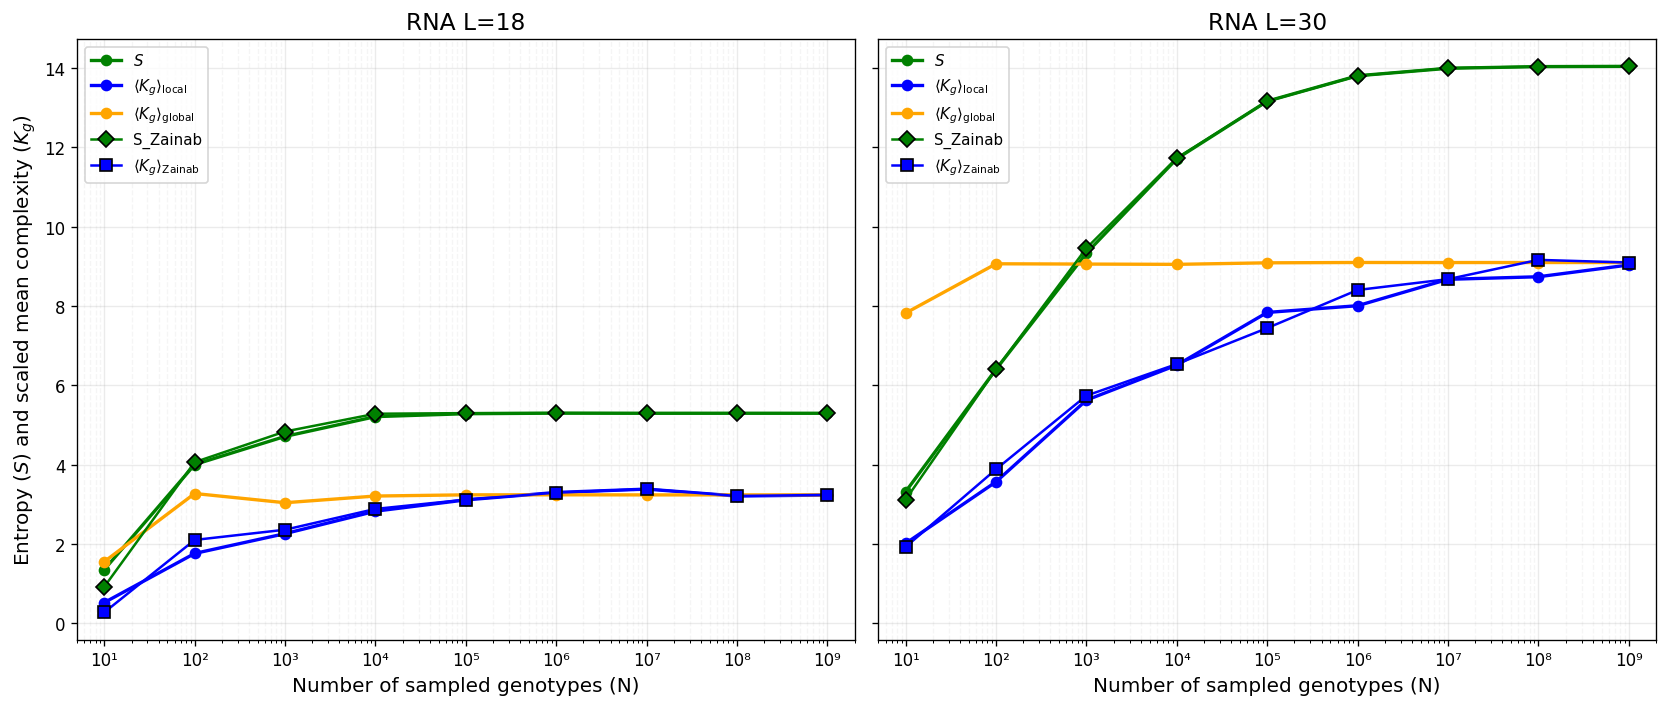

In [19]:
# Robust loader + column-name normalization + plot (with Zainab overlays & colors)
import os, sys, traceback
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- file paths (confirmed full paths) ---
p18 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_18/plot_b/plot_b_files/RNA_L18_global_local_sampling.csv")
p30 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_30/plot_b/plot_b_files/RNA_L30_global_local_sampling.csv")

# Excel summary files (dataset_B)
b18 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_18/plot_b/plot_b_files/Plot_B_data_RNA_L18.xlsx")
b30 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_30/plot_b/plot_b_files/Plot_B_data_RNA_L30.xlsx")

paths = [p18, p30]
bs = [b18, b30]

# --- environment info (helpful) ---
print("cwd:", os.getcwd())
print("python executable:", sys.executable)
print("process id:", os.getpid())
print("USER:", os.environ.get("USER") or os.environ.get("USERNAME"))
print()

# --- quick checks for CSVs and Excels ---
for p in paths + bs:
    print(f"Checking: {p}")
    print("  exists():", p.exists())
    try:
        st = p.stat()
        print("  size (bytes):", st.st_size)
    except Exception as e:
        print("  stat error:", e)
    print()

# --- robust read functions ---
def read_csv_robust(path):
    try:
        df = pd.read_csv(path, sep=",", engine="c", low_memory=False)
        return df
    except Exception as e:
        print("pd.read_csv(engine='c') failed for", path, "->", repr(e))
        try:
            df = pd.read_csv(path, engine="python")
            return df
        except Exception as e2:
            print("Fallback read failed for", path, "->", repr(e2))
            traceback.print_exc()
            return None

def read_excel_robust(path):
    try:
        df = pd.read_excel(path)  # default: first sheet
        return df
    except Exception as e:
        print("pd.read_excel failed for", path, "->", repr(e))
        traceback.print_exc()
        return None

# --- load CSVs ---
df18 = read_csv_robust(p18)
df30 = read_csv_robust(p30)

# --- load dataset_B Excel summaries ---
bdf18 = read_excel_robust(b18)
bdf30 = read_excel_robust(b30)

# --- column-name normalization map (CSV + Excel variants) ---
COL_MAP = {
    # sample size candidates
    "Samples": "sample_size", "N": "sample_size", "n": "sample_size", "num_samples": "sample_size",
    "sampleSize": "sample_size", "n_samples": "sample_size", "N_unique": "sample_size",
    # entropy
    "Entropy": "entropy", "S": "entropy", "entropy": "entropy",
    # scaled/global/local
    "GlobalScaled": "scaled_global", "Global": "scaled_global", "scaled_global": "scaled_global",
    "LocalScaled": "scaled_local", "Local": "scaled_local", "scaled_local": "scaled_local",
    # unscaled / simple mean
    "UnscaledMean": "simple_mean", "unscaled": "simple_mean", "simple_mean": "simple_mean",
    # dataset_B complexity column names
    "Complexity": "complexity", "complexity": "complexity", "K": "complexity"
}

def normalize_columns(df):
    if df is None:
        return None
    rename = {}
    for col in list(df.columns):
        if col in COL_MAP:
            rename[col] = COL_MAP[col]
        else:
            low = col.lower()
            for k, v in COL_MAP.items():
                if k.lower() == low:
                    rename[col] = v
                    break
    if rename:
        df = df.rename(columns=rename)
    return df

df18 = normalize_columns(df18)
df30 = normalize_columns(df30)
bdf18 = normalize_columns(bdf18)
bdf30 = normalize_columns(bdf30)

# --- ensure numeric and sorting for all dataframes ---
def prepare_df(df, name="df"):
    if df is None:
        print(f"{name}: DataFrame is None")
        return None
    # Convert known numeric columns to numeric dtype
    for numeric_col in ["sample_size", "entropy", "scaled_local", "scaled_global", "simple_mean", "complexity"]:
        if numeric_col in df.columns:
            df[numeric_col] = pd.to_numeric(df[numeric_col], errors="coerce")
    # If sample_size exists, sort by it
    if "sample_size" in df.columns and df["sample_size"].notna().any():
        df = df.sort_values("sample_size").reset_index(drop=True)
    return df

df18 = prepare_df(df18, "L=18")
df30 = prepare_df(df30, "L=30")
bdf18 = prepare_df(bdf18, "B L=18")
bdf30 = prepare_df(bdf30, "B L=30")

# --- quick diagnostics ---
for name, df in [("L=18", df18), ("L=30", df30), ("B L=18", bdf18), ("B L=30", bdf30)]:
    print(f"--- {name} diagnostics ---")
    if df is None:
        print(" DataFrame is None")
    else:
        print(" shape:", df.shape)
        print(" columns:", list(df.columns))
        print(df.head().to_string(index=False))
    print()

# --- plotting (robust) ---
if df18 is None and df30 is None:
    print("No data to plot. Aborting.")
else:
    plt.rcParams.update({"figure.dpi": 120})
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # Panels: (csv_df, title, axis, bdf)
    panels = [(df18, "RNA L=18", axes[0], bdf18), (df30, "RNA L=30", axes[1], bdf30)]

    # color map updates: local is blue now
    colors = {"entropy": "green", "local": "blue", "global": "orange"}

    def safe_plot(ax, x, y, *args, label=None, **kwargs):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.any():
            ax.semilogx(x[mask], y[mask], *args, label=label, **kwargs)
        else:
            print(f"[INFO] Nothing to plot for '{label}' (no finite pairs).")

    for df, title, ax, bdf in panels:
        if df is None or df.shape[0] == 0:
            ax.set_title(title + " (no data)", fontsize=14)
            ax.set_xlabel("Number of sampled genotypes (N)")
            continue

        # x axis: prefer normalized sample_size, else try 'Samples' fallback, else index
        if "sample_size" in df.columns and df["sample_size"].notna().any():
            N = df["sample_size"].values
        elif "Samples" in df.columns and pd.to_numeric(df["Samples"], errors="coerce").notna().any():
            N = pd.to_numeric(df["Samples"], errors="coerce").values
        else:
            print(f"[WARN] Using index for x-axis in {title}.")
            N = np.arange(1, len(df) + 1)

        # main CSV series (S, local, global) - normalized names used
        S = df["entropy"].values if "entropy" in df.columns else np.full(len(N), np.nan)
        Kg_local = df["scaled_local"].values if "scaled_local" in df.columns else np.full(len(N), np.nan)
        Kg_global = df["scaled_global"].values if "scaled_global" in df.columns else np.full(len(N), np.nan)

        # plot main series
        safe_plot(ax, N, S, "o-", color=colors["entropy"], lw=2, markersize=6, label=r"$S$")
        safe_plot(ax, N, Kg_local, "o-", color=colors["local"], lw=2, markersize=6,
                  label=r"$\langle K_g\rangle_{\mathrm{local}}$")
        safe_plot(ax, N, Kg_global, "o-", color=colors["global"], lw=2, markersize=6,
                  label=r"$\langle K_g\rangle_{\mathrm{global}}$")

        # --- overlay dataset_B summary statistics (Zainab modifications) ---
        if bdf is not None and "sample_size" in bdf.columns:
            Nb = bdf["sample_size"].values

            # S_Zainab: green diamonds connected with green lines
            if "entropy" in bdf.columns:
                Sb = bdf["entropy"].values
                mask = np.isfinite(Nb) & np.isfinite(Sb)
                if mask.any():
                    ax.semilogx(Nb[mask], Sb[mask], "D-", markersize=7,
                                markerfacecolor=colors["entropy"], markeredgecolor="black",
                                color=colors["entropy"], lw=1.5, label="S_Zainab")

            # Complexity_Zainab: red squares connected with red lines
            if "complexity" in bdf.columns:
                Kb = bdf["complexity"].values
                mask = np.isfinite(Nb) & np.isfinite(Kb)
                if mask.any():
                    ax.semilogx(Nb[mask], Kb[mask], "s-", markersize=7,
                                markerfacecolor="blue", markeredgecolor="black",
                                color="blue", lw=1.5, label=r"$\langle K_g\rangle_\mathrm{Zainab}$")
        else:
            if bdf is None:
                print(f"[INFO] No dataset_B found for {title}.")
            else:
                print(f"[WARN] dataset_B for {title} missing 'sample_size' column; skipping.")

        ax.set_title(title, fontsize=14)
        ax.set_xscale("log")
        ax.set_xlim(5, 2_000_000_000)
        ax.set_xlabel("Number of sampled genotypes (N)", fontsize=12)
        ax.grid(True, which="major", ls="-", alpha=0.25)
        ax.grid(True, which="minor", ls="--", alpha=0.12)

        # place legend (avoid duplicate labels by letting matplotlib handle repeats)
        ax.legend(fontsize=9, loc="upper left")

    axes[0].set_ylabel(r"Entropy ($S$) and scaled mean complexity ($K_g$)", fontsize=12)

    x_ticks = [10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000]
    x_tick_labels = ['10¹','10²','10³','10⁴','10⁵','10⁶','10⁷','10⁸','10⁹']
    for ax in axes:
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_tick_labels, rotation=0)

    plt.tight_layout()

    # Save figure
    out = Path.cwd() / "RNA_L18_L30_entropy_with_Zainab_plot.png"
    plt.savefig(out, dpi=200)
    print("Saved figure to:", out)
    plt.show()

Paper ready plots

Generating figure for RNA L=18
Saved: RNA_L18_S_and_Kg.png



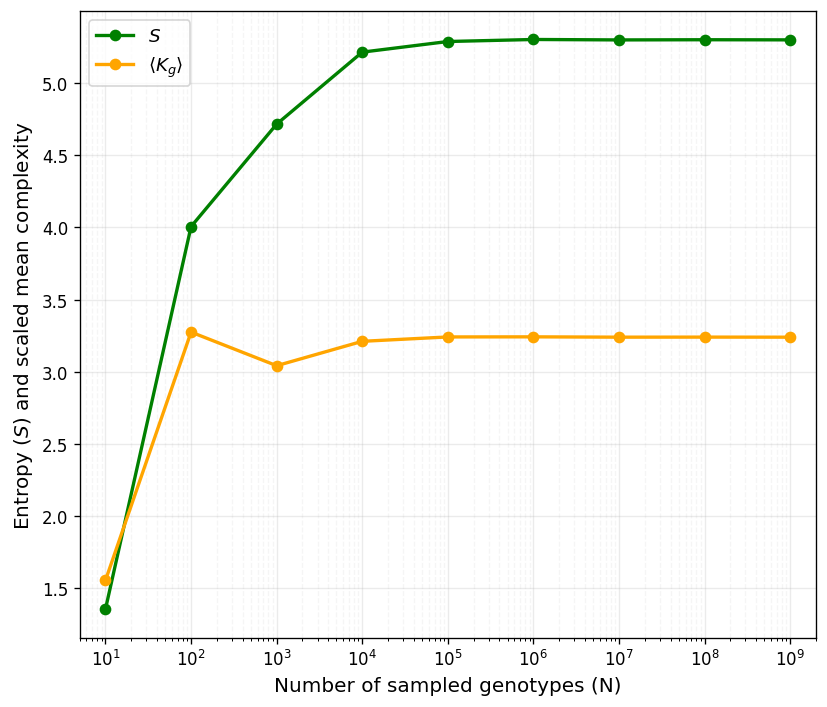

Generating figure for RNA L=30
Saved: RNA_L30_S_and_Kg.png



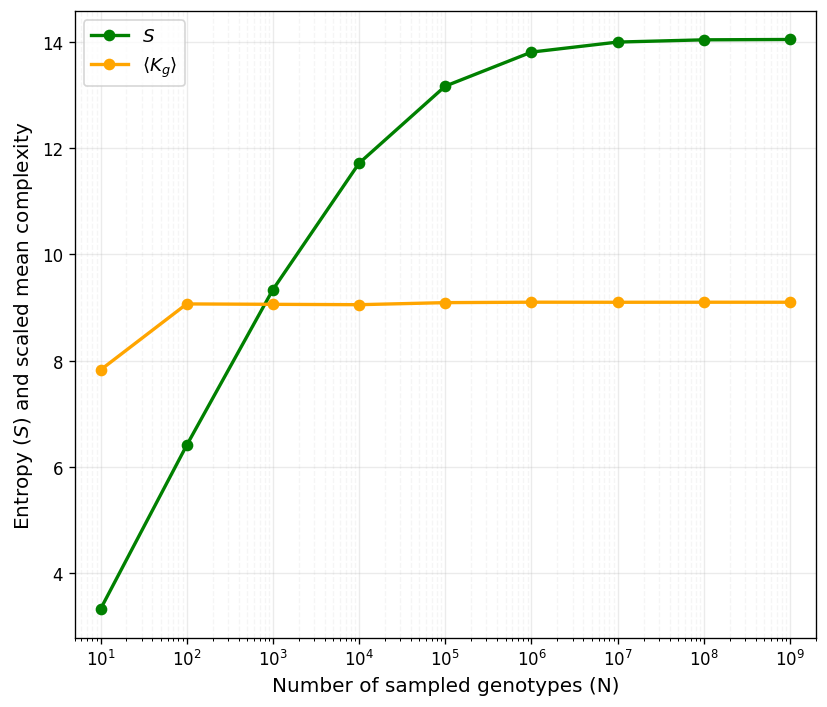

In [21]:
# Create two separate figures (L=18 and L=30)
# Showing only S and <K_g>_global (labeled as <K_g>)
# No figure titles

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- file paths ---
p18 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_18/plot_b/plot_b_files/RNA_L18_global_local_sampling.csv")
p30 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_30/plot_b/plot_b_files/RNA_L30_global_local_sampling.csv")

# --- read CSVs ---
df18 = pd.read_csv(p18)
df30 = pd.read_csv(p30)

# --- normalize column names ---
rename_map = {
    "Samples": "sample_size",
    "Entropy": "entropy",
    "GlobalScaled": "scaled_global"
}

df18 = df18.rename(columns=rename_map)
df30 = df30.rename(columns=rename_map)

# --- convert to numeric and sort ---
for df in (df18, df30):
    df["sample_size"] = pd.to_numeric(df["sample_size"], errors="coerce")
    df["entropy"] = pd.to_numeric(df["entropy"], errors="coerce")
    df["scaled_global"] = pd.to_numeric(df["scaled_global"], errors="coerce")
    df.sort_values("sample_size", inplace=True)

# --- plotting function ---
def make_plot(df, label_text, output_name):

    print(f"Generating figure for {label_text}")

    N = df["sample_size"].values
    S = df["entropy"].values
    Kg = df["scaled_global"].values

    plt.figure(figsize=(7, 6), dpi=120)

    plt.semilogx(N, S, "o-", linewidth=2, markersize=6,
                 label=r"$S$", color="green")

    plt.semilogx(N, Kg, "o-", linewidth=2, markersize=6,
                 label=r"$\langle K_g \rangle$", color="orange")

    plt.xlabel("Number of sampled genotypes (N)", fontsize=12)
    plt.ylabel(r"Entropy ($S$) and scaled mean complexity", fontsize=12)

    plt.xscale("log")
    plt.xlim(5, 2_000_000_000)

    plt.grid(True, which="major", alpha=0.25)
    plt.grid(True, which="minor", linestyle="--", alpha=0.12)

    plt.legend(fontsize=11)
    plt.tight_layout()

    plt.savefig(output_name, dpi=300)
    print(f"Saved: {output_name}\n")

    plt.show()


# --- generate two separate figures ---
make_plot(df18, "RNA L=18", "RNA_L18_S_and_Kg.png")
make_plot(df30, "RNA L=30", "RNA_L30_S_and_Kg.png")

print values of the plotted points

In [22]:
# Print values of the plotted points (N, S, <K_g>)

import pandas as pd
from pathlib import Path

# --- file paths ---
p18 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_18/plot_b/plot_b_files/RNA_L18_global_local_sampling.csv")
p30 = Path("/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/RNA/L_30/plot_b/plot_b_files/RNA_L30_global_local_sampling.csv")

# --- read and normalize ---
def load_and_prepare(path):
    df = pd.read_csv(path)
    df = df.rename(columns={
        "Samples": "sample_size",
        "Entropy": "entropy",
        "GlobalScaled": "scaled_global"
    })
    df["sample_size"] = pd.to_numeric(df["sample_size"], errors="coerce")
    df["entropy"] = pd.to_numeric(df["entropy"], errors="coerce")
    df["scaled_global"] = pd.to_numeric(df["scaled_global"], errors="coerce")
    df = df.sort_values("sample_size")
    return df

df18 = load_and_prepare(p18)
df30 = load_and_prepare(p30)

# --- print values ---
def print_values(df, label):
    print(f"\n=== {label} ===")
    for _, row in df.iterrows():
        print(f"N={int(row['sample_size']):>10} | "
              f"S={row['entropy']:8.4f} | "
              f"<K_g>={row['scaled_global']:8.4f}")

print_values(df18, "RNA L=18")
print_values(df30, "RNA L=30")


=== RNA L=18 ===
N=        10 | S=  1.3568 | <K_g>=  1.5557
N=       100 | S=  4.0050 | <K_g>=  3.2745
N=      1000 | S=  4.7142 | <K_g>=  3.0418
N=     10000 | S=  5.2127 | <K_g>=  3.2106
N=    100000 | S=  5.2863 | <K_g>=  3.2409
N=   1000000 | S=  5.3003 | <K_g>=  3.2416
N=  10000000 | S=  5.2973 | <K_g>=  3.2393
N= 100000000 | S=  5.2985 | <K_g>=  3.2398
N=1000000000 | S=  5.2977 | <K_g>=  3.2392

=== RNA L=30 ===
N=        10 | S=  3.3219 | <K_g>=  7.8241
N=       100 | S=  6.4073 | <K_g>=  9.0668
N=      1000 | S=  9.3363 | <K_g>=  9.0594
N=     10000 | S= 11.7164 | <K_g>=  9.0524
N=    100000 | S= 13.1672 | <K_g>=  9.0911
N=   1000000 | S= 13.8077 | <K_g>=  9.0995
N=  10000000 | S= 13.9964 | <K_g>=  9.0979
N= 100000000 | S= 14.0386 | <K_g>=  9.0988
N=1000000000 | S= 14.0451 | <K_g>=  9.0985
